## Forecast 2026/27 + Model comparison (table models)

Train on **league tables** through 2025/26, predict the **2026/27 table** for the confirmed squad.

Both models output a **full predicted table** (points + positions) — no match-by-match simulation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_static,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    predict_table,
    pl_2627_squad,
    STUDENT_T_NU,
    FORECAST_TRAIN_SEASONS,
)


In [2]:
matches = load_matches()
forecast_teams = pl_2627_squad(matches)
tables = load_season_tables(matches, FORECAST_TRAIN_SEASONS)

print(f"Forecast 2026/27: {len(forecast_teams)} teams")
for i, t in enumerate(forecast_teams, 1):
    print(f"  {i:2d}. {t}")


Forecast 2026/27: 20 teams
   1. Arsenal
   2. Aston Villa
   3. Bournemouth
   4. Brentford
   5. Brighton
   6. Chelsea
   7. Coventry
   8. Crystal Palace
   9. Everton
  10. Fulham
  11. Hull
  12. Ipswich
  13. Leeds
  14. Liverpool
  15. Man City
  16. Man United
  17. Newcastle
  18. Nott'm Forest
  19. Sunderland
  20. Tottenham


### Model 1 — static table model


In [3]:
stan1, team_to_idx, _, feature_stats1 = prepare_table_stan_static(
    tables, FORECAST_TRAIN_SEASONS
)
stan1["nu"] = STUDENT_T_NU
fit1 = CmdStanModel(stan_file="stan/table_static.stan").sample(
    data=stan1, seed=42, chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=1000, adapt_delta=0.99, show_progress=True,
)
print(fit1.diagnose())


16:14:32 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:14:35 - cmdstanpy - INFO - CmdStan done processing.
16:14:35 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
Exception: student_t_lpdf: Scale parameter is inf, but mu


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [4]:
feat1 = build_forecast_features(
    matches, "2526", forecast_teams, FORECAST_TRAIN_SEASONS, feature_stats1
)
pred1 = predict_table(
    fit1, forecast_teams, team_to_idx, model="static", team_features=feat1, n_sims=800, seed=1
)
pred1 = pred1.rename(columns={"pos_median": "pos_m1", "pts_median": "pts_m1"})
pred1.head(10)


,team,pos_m1,pos_mean,pts_m1,pts_mean
0,Arsenal,1.0,1.70625,79.167396,78.974045
1,Man United,2.0,2.70625,72.557746,72.825081
2,Man City,3.0,2.95750,72.334117,72.103798
3,Bournemouth,7.0,7.79125,57.787417,57.401534
4,Brighton,7.5,8.40000,56.385980,56.304937
5,Liverpool,8.0,8.75625,55.670769,55.738699
6,Nott'm Forest,9.0,9.79500,53.727709,53.793948
7,Aston Villa,10.0,10.36875,52.945125,52.896928
8,Newcastle,11.0,11.29875,51.464801,51.559053
9,Coventry,11.0,11.16125,51.392702,51.627116


### Model 2 — hierarchical table model (2526 skills)


In [5]:
stan2, team_to_idx2, _, season_to_idx, feature_stats2 = prepare_table_stan_hierarchical(
    tables, FORECAST_TRAIN_SEASONS
)
stan2["nu"] = STUDENT_T_NU
last_season_idx = season_to_idx["2526"]

fit2 = CmdStanModel(stan_file="stan/table_hierarchical.stan").sample(
    data=stan2, seed=42, chains=4, parallel_chains=4,
    iter_warmup=1500, iter_sampling=1500, adapt_delta=0.99, show_progress=True,
)
print(fit2.diagnose())


16:14:40 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:14:50 - cmdstanpy - INFO - CmdStan done processing.
16:14:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Location parameter is nan, but must be finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
Exception: student_t_lp


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
feat2 = build_forecast_features(
    matches, "2526", forecast_teams, FORECAST_TRAIN_SEASONS, feature_stats2
)
pred2 = predict_table(
    fit2,
    forecast_teams,
    team_to_idx2,
    model="hierarchical",
    last_season_index=last_season_idx,
    team_features=feat2,
    n_sims=800,
    seed=2,
)
pred2 = pred2.rename(columns={"pos_median": "pos_m2", "pts_median": "pts_m2"})
pred2.head(10)


,team,pos_m2,pos_mean,pts_m2,pts_mean
0,Arsenal,1.0,1.37250,82.577694,82.325653
1,Man City,2.0,2.32125,75.044688,75.026829
2,Man United,3.0,3.27500,70.495694,70.289685
3,Aston Villa,6.0,6.74500,60.427846,60.091971
4,Bournemouth,7.0,7.63750,58.211740,58.308169
5,Liverpool,7.0,7.92875,57.751455,57.638864
6,Brighton,9.0,9.38125,55.195049,55.330276
7,Coventry,11.0,11.28375,52.472619,52.349991
8,Ipswich,11.0,11.13125,52.943742,52.743678
9,Sunderland,11.0,11.48500,52.274189,52.082036


### Side-by-side forecast 2026/27


In [7]:
comparison = pred1[["team","pos_m1","pts_m1"]].merge(
    pred2[["team","pos_m2","pts_m2"]], on="team"
)
comparison["pos_diff"] = comparison["pos_m1"] - comparison["pos_m2"]
comparison.sort_values("pos_m1")


,team,pos_m1,pts_m1,pos_m2,pts_m2,pos_diff
0,Arsenal,1.0,79.167396,1.0,82.577694,0.0
1,Man United,2.0,72.557746,3.0,70.495694,-1.0
2,Man City,3.0,72.334117,2.0,75.044688,1.0
3,Bournemouth,7.0,57.787417,7.0,58.211740,0.0
4,Brighton,7.5,56.385980,9.0,55.195049,-1.5
5,Liverpool,8.0,55.670769,7.0,57.751455,1.0
6,Nott'm Forest,9.0,53.727709,14.0,48.943516,-5.0
7,Aston Villa,10.0,52.945125,6.0,60.427846,4.0
10,Hull,11.0,51.130650,11.0,52.403621,0.0
9,Coventry,11.0,51.392702,11.0,52.472619,0.0


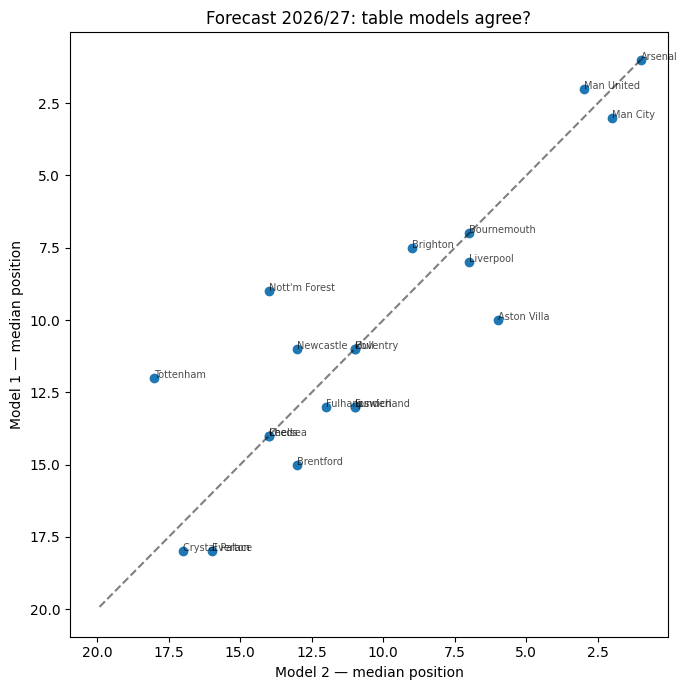

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(comparison["pos_m2"], comparison["pos_m1"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_m2"], r["pos_m1"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Model 2 — median position")
ax.set_ylabel("Model 1 — median position")
ax.set_title("Forecast 2026/27: table models agree?")
ax.invert_xaxis(); ax.invert_yaxis()
plt.tight_layout(); plt.show()


### WAIC / LOO (team-season rows)


In [9]:
idata1 = az.from_cmdstanpy(fit1)
idata2 = az.from_cmdstanpy(fit2)
loo1, loo2 = az.loo(idata1), az.loo(idata2)
waic1, waic2 = az.waic(idata1), az.waic(idata2)

print("LOO Model 1:", loo1)
print("LOO Model 2:", loo2)
print(f"Delta ELPD (M2-M1): {loo2.elpd_loo - loo1.elpd_loo:.1f}")
print(az.compare({"M1 static table": idata1, "M2 hierarchical table": idata2}, ic="loo"))


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.

LOO Model 1: Computed from 4000 posterior samples and 340 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1163.92    13.18
p_loo       29.09        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      340  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

LOO Model 2: Computed from 6000 posterior samples and 340 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1166.50    12.35
p_loo      207.09        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      325   95.6%
   (0.70, 1]   (bad)        15    4.4%
   (1, Inf)   (very bad)    0    0.0%

Delta ELPD (M2-M1): -2.6
                       rank     elpd_loo       p_loo  elpd_diff    weight  \
M1 static table           0 -1163.920596   29.086684   0.000000  0.589627   
M2 hierarch

/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


### Final assessment

- **Unit of prediction:** league **table** (points → rank), not single matches.
- **LOO** compares fit on historical **team-season points**; better ELPD ⇒ better table-level likelihood.
- For 2026/27, compare `pos_m1` vs `pos_m2`; large differences ⇒ report both forecasts.
